### Imports

In [1]:
import sys
import numpy as np
import pytest
import matplotlib.pyplot as plt
sys.path.append("../src")

from system import System
from polymer import Polymer

from mpcd import *
from md import verlet_step
from forces import forcesOnPolymer
from observables import * 

### Parameters of Simulation

In [62]:
params = {
    "box": np.array([10.0, 10.0, 10.0]),

    # MPCD solvent
    "n_solvent": 100,
    "solvent_mass": 1.0,
    "a": 1.0,
    "h": 0.1,
    "alpha": np.pi / 2,
    "kBT": 0.75,

    # Polymer
    "n_monomers": 30,
    "polymer_mass": 3.0,
    "bond_length": 0.25,
    "k_bond": 100.0,

    # MD
    "n_md_substeps": 500,
    "n_mpcd_steps": 5000,

    # Random seed
    "seed": 3310,
}
dt_md = params["h"] / params["n_md_substeps"]

### Creation of a Polymer and a System

In [63]:
system = System(
    N=params["n_solvent"],
    box=params["box"],
    m=params["solvent_mass"],
    a=params["a"],
    h=params["h"],
    alpha=params["alpha"],
    kBT=params["kBT"],
    seed=params["seed"],
)

polymer = Polymer(
    nMonomers=params["n_monomers"],
    bondLength=params["bond_length"],
    dt=dt_md,
    m=params["polymer_mass"],
    k=params["k_bond"],
    box=params["box"],
    kBT=params["kBT"],
    seed=params["seed"] + 42,
)

forcesOnPolymer(polymer)

### Simulation

In [64]:
history = {
    "step": [],

    "polymer_E": [],
    "polymer_K": [],
    "polymer_U": [],

    "mean_bond_length": [],
    "max_bond_length": [],
    "polymer_momentum_norm": [],

    "solvent_K": [],
    "solvent_momentum_norm": [],
}

P_polymer_0 = total_momentum(polymer)
P_solvent_0 = total_momentum(system)

for step in range(params["n_mpcd_steps"]):
    # 1. MPCD streaming
    stream(system)

    # 2. Polymer MD substeps
    for _ in range(params["n_md_substeps"]):
        verlet_step(polymer, dt_md, forcesOnPolymer)

    # 3. MPCD collision
    # for now:
    #collide(system)

    collideCoupled(system, polymer)

    # 4. Record observables
    lengths = bond_lengths(polymer)

    history["step"].append(step)

    history["polymer_K"].append(polymer_kinetic_energy(polymer))
    history["polymer_U"].append(polymer_bond_energy(polymer))
    history["polymer_E"].append(polymer_total_energy(polymer))

    history["mean_bond_length"].append(lengths.mean())
    history["max_bond_length"].append(lengths.max())
    history["polymer_momentum_norm"].append(
        np.linalg.norm(total_momentum(polymer) - P_polymer_0)
    )

    history["solvent_K"].append(system_kinetic(system))
    history["solvent_momentum_norm"].append(
        np.linalg.norm(total_momentum(system) - P_solvent_0)
    )
    
for key in history:
    history[key] = np.array(history[key])

### Results
#### Polymer

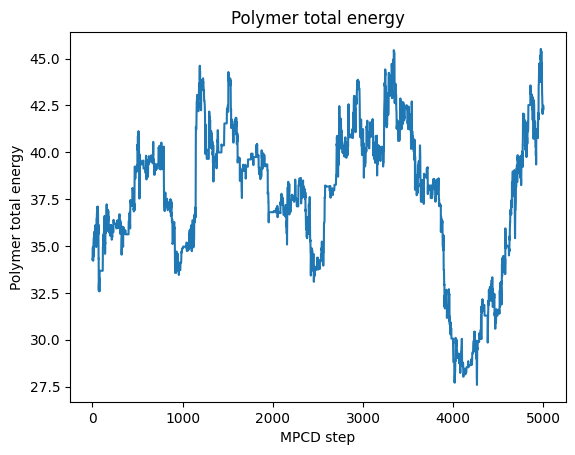

In [65]:
plt.figure()
plt.plot(history["step"], history["polymer_E"])
plt.xlabel("MPCD step")
plt.ylabel("Polymer total energy")
plt.title("Polymer total energy")
plt.show()

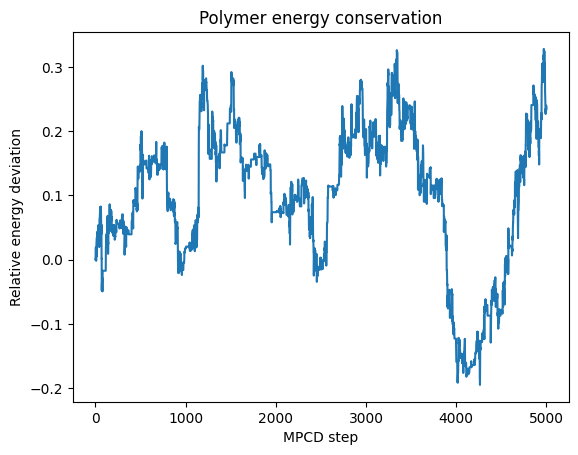

In [66]:
E0 = history["polymer_E"][0]

plt.figure()
plt.plot(history["step"], (history["polymer_E"] - E0) / abs(E0))
plt.xlabel("MPCD step")
plt.ylabel("Relative energy deviation")
plt.title("Polymer energy conservation")
plt.show()

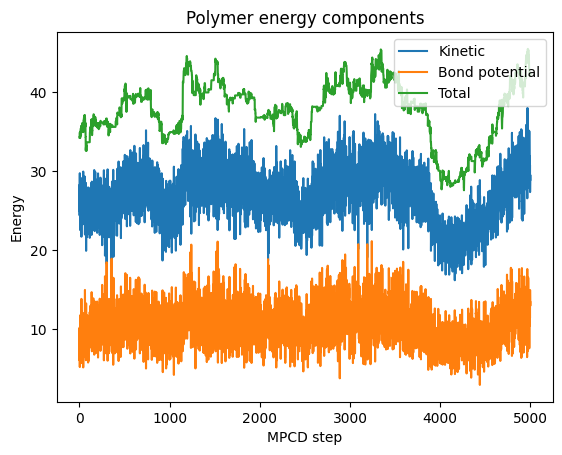

In [67]:
plt.figure()
plt.plot(history["step"], history["polymer_K"], label="Kinetic")
plt.plot(history["step"], history["polymer_U"], label="Bond potential")
plt.plot(history["step"], history["polymer_E"], label="Total")
plt.xlabel("MPCD step")
plt.ylabel("Energy")
plt.title("Polymer energy components")
plt.legend()
plt.show()

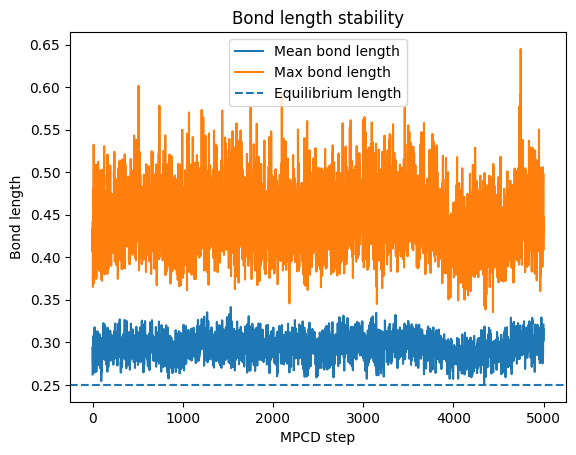

In [68]:
plt.figure()
plt.plot(history["step"], history["mean_bond_length"], label="Mean bond length")
plt.plot(history["step"], history["max_bond_length"], label="Max bond length")
plt.axhline(params["bond_length"], linestyle="--", label="Equilibrium length")
plt.xlabel("MPCD step")
plt.ylabel("Bond length")
plt.title("Bond length stability")
plt.legend()
plt.show()

### Polymer in 3D

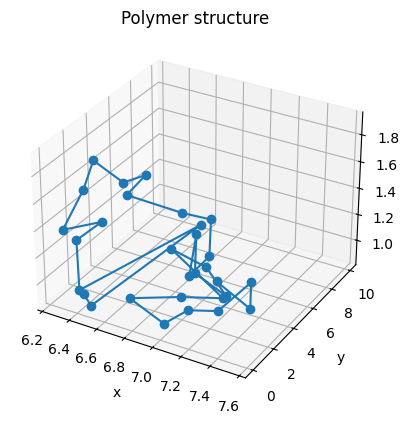

In [69]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

r = polymer.r

ax.plot(r[:, 0], r[:, 1], r[:, 2], marker="o")
#ax.set_xlim(0, params["box"][0])
#ax.set_ylim(0, params["box"][1])
#ax.set_zlim(0, params["box"][2])

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Polymer structure")

plt.show()

### System

In [70]:
history["total_E"] = history["solvent_K"] + history["polymer_E"]

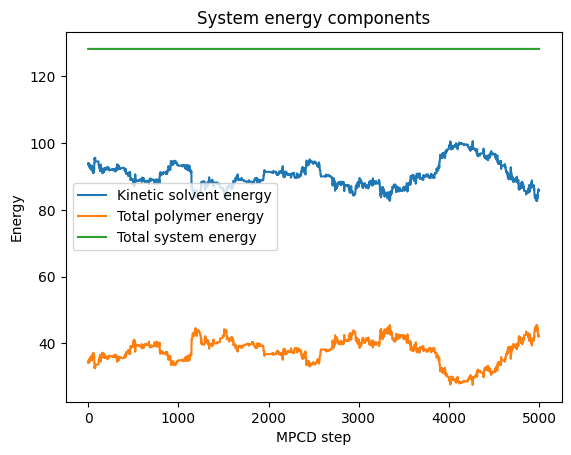

In [71]:
plt.figure()
plt.plot(history["step"], history["solvent_K"], label="Kinetic solvent energy")
plt.plot(history["step"], history["polymer_E"], label="Total polymer energy")
plt.plot(history["step"], history["total_E"], label="Total system energy")
plt.xlabel("MPCD step")
plt.ylabel("Energy")
plt.title("System energy components")
plt.legend()
plt.show()

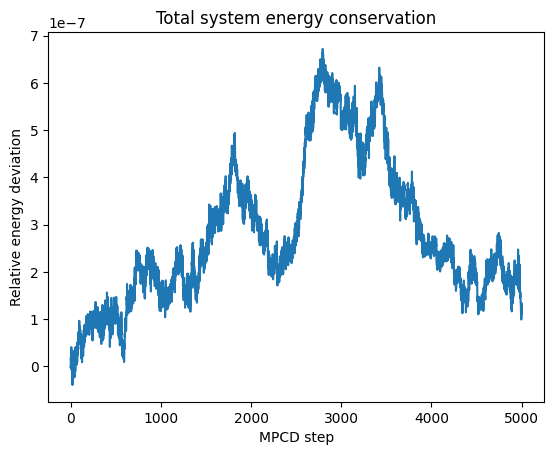

In [72]:
E0 = history["total_E"][0]

plt.figure()
plt.plot(history["step"], (history["total_E"] - E0) / abs(E0))
plt.xlabel("MPCD step")
plt.ylabel("Relative energy deviation")
plt.title("Total system energy conservation")
plt.show()